# 시계열 ACF 연습 (PyTorch)

`statsmodels` 결과와 PyTorch 직접 구현을 비교합니다.

In [ ]:
from statsmodels.tsa.stattools import acf as sm_acf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

## 1. ACF 구현

표본 자기상관(sample ACF):

$$\hat{\rho}(k) = \frac{\sum_{t=k}^{n-1}(x_t - \bar{x})(x_{t-k} - \bar{x})}{\sum_{t=1}^{n}(x_t - \bar{x})^2}$$

**구현 아이디어** (`conv1d` / `nn` 없이, for-loop 없이)
- `k`, `t` 격자를 `unsqueeze`로 브로드캐스팅
- lag $k$에서 `t >= k`인 시점만 `xc[t] * xc[t-k]` 합산
- 사용 연산: `mean`, `*`, `sum`, 인덱싱, `torch.arange`

In [18]:
def acf(x: torch.Tensor, max_lag: int) -> torch.Tensor:
    """
    표본 ACF. 텐서 인덱싱·브로드캐스팅만 사용.
    x: (n,) 1차원 시계열 → (max_lag+1,)
    """
    x = x.float().flatten()
    xc = x - x.mean()
    n = xc.numel()
    denom = (xc * xc).sum()

    k = torch.arange(max_lag + 1, device=x.device).unsqueeze(1)
    t = torch.arange(n, device=x.device).unsqueeze(0)
    valid = t >= k

    prod = xc[t] * xc[(t - k).clamp(min=0)]
    acov = (prod * valid).sum(dim=1)

    return acov / denom


## 2. 데이터 로드

In [20]:
df = pd.read_csv('../data/widget_sales.csv')
df.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


## 3. 원시 시계열 시각화

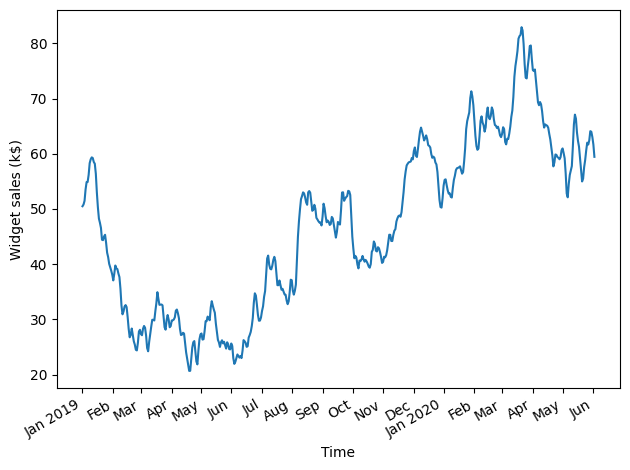

In [22]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498],
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug',
     'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

## 4. 원시 시계열 ACF — PyTorch vs statsmodels

In [23]:
MAX_LAG = 20

series = df['widget_sales'].to_numpy()
x = torch.tensor(series, dtype=torch.float32)

acf_pt = acf(x, MAX_LAG)
acf_sm = torch.tensor(sm_acf(series, nlags=MAX_LAG, fft=True), dtype=torch.float32)

print('pytorch vs statsmodels:', torch.allclose(acf_pt, acf_sm, atol=1e-5))
print(torch.stack([acf_pt, acf_sm], dim=1), '\n(columns: pytorch, statsmodels)')

pytorch vs statsmodels: True
tensor([[1.0000, 1.0000],
        [0.9955, 0.9955],
        [0.9860, 0.9860],
        [0.9753, 0.9753],
        [0.9648, 0.9648],
        [0.9545, 0.9545],
        [0.9443, 0.9443],
        [0.9341, 0.9341],
        [0.9242, 0.9242],
        [0.9151, 0.9151],
        [0.9068, 0.9068],
        [0.8987, 0.8987],
        [0.8904, 0.8904],
        [0.8817, 0.8817],
        [0.8727, 0.8727],
        [0.8634, 0.8634],
        [0.8536, 0.8536],
        [0.8434, 0.8434],
        [0.8329, 0.8329],
        [0.8224, 0.8224],
        [0.8127, 0.8127]]) 
(columns: pytorch, statsmodels)


## 5. 1차 차분 시계열

비정상 시계열은 차분 후 ACF 패턴이 달라집니다.

In [24]:
widget_sales_diff = np.diff(df['widget_sales'].to_numpy(), n=1)

### 차분 시계열 시각화

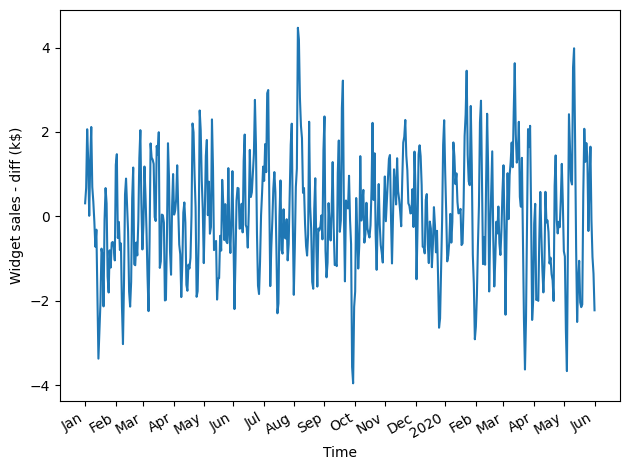

In [25]:
fig, ax = plt.subplots()

ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

n = len(widget_sales_diff)
tick_idx = [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, n - 1]
tick_idx = [i for i in tick_idx if i < n]
tick_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug',
               'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'][:len(tick_idx)]
plt.xticks(tick_idx, tick_labels)

fig.autofmt_xdate()
plt.tight_layout()

## 6. 차분 시계열 ACF — PyTorch vs statsmodels

In [26]:
MAX_LAG = 20

x = torch.tensor(widget_sales_diff, dtype=torch.float32)

acf_pt = acf(x, MAX_LAG)
acf_sm = torch.tensor(sm_acf(widget_sales_diff, nlags=MAX_LAG, fft=True), dtype=torch.float32)

print('pytorch vs statsmodels:', torch.allclose(acf_pt, acf_sm, atol=1e-5))
print(torch.stack([acf_pt, acf_sm], dim=1), '\n(columns: pytorch, statsmodels)')

pytorch vs statsmodels: True
tensor([[ 1.0000,  1.0000],
        [ 0.6099,  0.6099],
        [ 0.1410,  0.1410],
        [-0.0378, -0.0378],
        [-0.0458, -0.0458],
        [ 0.0070,  0.0070],
        [ 0.0161,  0.0161],
        [-0.0510, -0.0510],
        [-0.1031, -0.1031],
        [-0.0725, -0.0725],
        [-0.0028, -0.0028],
        [ 0.0564,  0.0564],
        [ 0.0513,  0.0513],
        [ 0.0212,  0.0212],
        [ 0.0281,  0.0281],
        [ 0.0439,  0.0439],
        [ 0.0477,  0.0477],
        [ 0.0210,  0.0210],
        [-0.0329, -0.0329],
        [-0.1107, -0.1107],
        [-0.1539, -0.1539]]) 
(columns: pytorch, statsmodels)
